# Cell-Type Annotation Benchmarking

Three approaches to cell-type annotation are compared here against the original authors' expert-labeled ground truth (`celltype_major`): marker-gene scoring, a classifier trained directly on this data, and CellTypist, a pretrained automated tool. This is the part of the project that most directly follows up on prior published work benchmarking scRNA-seq labelling algorithms — the goal isn't just to pick a winner, but to understand where and why each method succeeds or fails.

## Setup

In [ ]:
import os

IN_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in dir() else False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = "/content/drive/MyDrive/single-cell-breast-cancer-project"
else:
    PROJECT_DIR = "."

DATA_DIR = os.path.join(PROJECT_DIR, "data")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

print("Data directory:", DATA_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data directory: /content/drive/MyDrive/single-cell-breast-cancer-project/data


In [ ]:
!pip install scanpy anndata celltypist harmonypy gseapy scikit-learn scrublet leidenalg igraph

In [ ]:
import scanpy as sc
import anndata as ad
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, adjusted_rand_score, confusion_matrix

sc.settings.verbosity = 2
sc.settings.figdir = FIG_DIR

try:
    import psutil
    mem = psutil.virtual_memory()
    print(f"RAM available at start: {mem.available / (1024**3):.1f} GB of {mem.total / (1024**3):.1f} GB total")
except ImportError:
    print("(install psutil for a RAM check: !pip install psutil)")


RAM available at start: 11.3 GB of 12.7 GB total


Picking up from the clustered checkpoint saved at the end of the preprocessing notebook.

In [ ]:
adata = sc.read_h5ad(os.path.join(DATA_DIR, "adata_clustered_checkpoint.h5ad"))
print(adata)
assert adata.X.min() >= 0, "Expected log-normalized data here"
print("\nHighly variable genes available:", adata.var["highly_variable"].sum())


AnnData object with n_obs × n_vars = 98964 × 28468
    obs: 'donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'doublet_score', 'predicted_doublet', 'leiden'
    var: 'feature_name', 'feature_reference', 'feat

## Marker-gene scoring

The classic approach: score every cell against canonical marker genes for each expected type, then assign each cell to whichever type scores highest. `sc.tl.score_genes` computes each cell's average expression across the marker set, offset against a randomly-selected reference gene set — this controls for the fact that broadly high-expression genes score high everywhere regardless of biological specificity.

One thing worth flagging going in, not after the fact: unlike the other two methods, this one is being asked to distinguish Cancer Epithelial from Normal Epithelial, which is a genuinely hard case for a marker-based approach. Malignancy isn't a matter of a cell expressing a different identity marker — it's a genomic property (copy-number alterations, driver mutations), and there's no clean canonical gene that marks "this cell is cancerous." If this method underperforms specifically on that pair while doing fine elsewhere, that's expected, and it's actually informative rather than a failure of the approach — it's part of why the dataset's authors used copy-number inference for that specific distinction rather than markers, and it's revisited directly in the final malignancy analysis.

In [ ]:
marker_genes = {
    "B-cells": ["MS4A1", "CD79A", "CD79B", "CD19"],
    "Plasmablasts": ["MZB1", "JCHAIN", "XBP1", "DERL3"],
    "T-cells": ["CD3D", "CD3E", "CD3G", "CD2", "TRBC2"],
    "Myeloid": ["CD68", "LYZ", "CD14", "FCGR3A", "ITGAM", "AIF1"],
    "Endothelial": ["PECAM1", "VWF", "CLDN5", "CDH5"],
    "CAFs": ["COL1A1", "COL1A2", "COL3A1", "PDGFRB", "DCN", "FAP"],
    "PVL": ["ACTA2", "RGS5", "NOTCH3", "MCAM"],
    "Cancer Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT19"],
    "Normal Epithelial": ["EPCAM", "KRT8", "KRT18", "KRT14", "KRT5"],
}

for ct, genes in marker_genes.items():
    valid_genes = [g for g in genes if g in adata.var_names]
    missing = set(genes) - set(valid_genes)
    if missing:
        print(f"Note: {ct} markers not found in this dataset: {missing}")
    if not valid_genes:
        print(f"WARNING: none of {ct}'s markers were found — skipping this cell type "
              f"(it will never be predicted). Check gene symbol spelling/capitalization.")
        adata.obs[f"score_{ct}"] = -np.inf  # never wins the argmax below
        continue
    sc.tl.score_genes(adata, valid_genes, score_name=f"score_{ct}")

score_cols = [f"score_{ct}" for ct in marker_genes]
adata.obs["marker_pred"] = adata.obs[score_cols].idxmax(axis=1).str.replace("score_", "", regex=False)

acc_marker = accuracy_score(adata.obs["celltype_major"], adata.obs["marker_pred"])
print(f"\nMarker-scoring overall accuracy: {acc_marker:.3f}")
print("\nPer-class performance:")
print(classification_report(adata.obs["celltype_major"], adata.obs["marker_pred"], zero_division=0))


computing score 'score_B-cells'
    finished (0:00:04)
computing score 'score_Plasmablasts'
    finished (0:00:01)
computing score 'score_T-cells'
    finished (0:00:01)
computing score 'score_Myeloid'
    finished (0:00:01)
computing score 'score_Endothelial'
    finished (0:00:01)
computing score 'score_CAFs'
    finished (0:00:01)
Note: PVL markers not found in this dataset: {'RGS5'}
computing score 'score_PVL'
    finished (0:00:01)
computing score 'score_Cancer Epithelial'
    finished (0:00:01)
computing score 'score_Normal Epithelial'
    finished (0:00:01)

Marker-scoring overall accuracy: 0.845

Per-class performance:
                   precision    recall  f1-score   support

          B-cells       0.61      0.93      0.74      3201
             CAFs       0.73      0.98      0.84      6529
Cancer Epithelial       0.88      0.80      0.84     23794
      Endothelial       0.92      0.94      0.93      7562
          Myeloid       0.90      0.94      0.92      9529
Normal Epi

Overall accuracy of 84.5% sounds reasonable until looking at the per-class breakdown: Normal Epithelial comes in at 0.39 precision / 0.41 recall — close to a coin flip, and exactly the predicted weak point. Everything else is comfortably above 0.7. PVL also underperforms somewhat (0.75 recall) — worth a look at the confusion matrix later to see what it's being confused with.

## A trained classifier

Logistic regression trained directly on this dataset's own highly variable genes, rather than a fixed marker list — in principle this should adapt to whatever actually distinguishes cell types in this specific data, at the cost of needing labeled training data to begin with (which is fine here, since the ground-truth labels already exist).

The train/test split is done **by patient, not by cell** — `GroupShuffleSplit` on `donor_id`. This matters more than it might look: cells from the same patient are highly correlated with each other (shared genetics, shared tumor microenvironment), so a random per-cell split would let the classifier partly learn "which patient is this" as a shortcut, inflating accuracy in a way that wouldn't generalize to a genuinely new patient. Holding out entire donors is the honest test — can the classifier label cell types correctly in a patient it has never seen a single cell from.

In [ ]:
hvg_mask = adata.var["highly_variable"].values
adata_hvg_for_clf = adata[:, hvg_mask]
X_features = adata_hvg_for_clf.X.toarray() if hasattr(adata_hvg_for_clf.X, "toarray") else adata_hvg_for_clf.X
y = adata.obs["celltype_major"].values
groups = adata.obs["donor_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=0)
train_idx, test_idx = next(gss.split(X_features, y, groups=groups))

train_donors = set(groups[train_idx])
test_donors = set(groups[test_idx])
print(f"Train donors: {len(train_donors)}, Test donors: {len(test_donors)}")
print("Donor overlap between train/test (must be empty):", train_donors & test_donors)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_features[train_idx], y[train_idx])
y_pred = clf.predict(X_features[test_idx])

acc_clf = accuracy_score(y[test_idx], y_pred)
print(f"\nTrained classifier accuracy (held-out patients): {acc_clf:.3f}")
print("\nPer-class performance:")
print(classification_report(y[test_idx], y_pred, zero_division=0))


Train donors: 18, Test donors: 8
Donor overlap between train/test (must be empty): set()

Trained classifier accuracy (held-out patients): 0.954

Per-class performance:
                   precision    recall  f1-score   support

          B-cells       0.94      0.95      0.94      1153
             CAFs       0.53      0.94      0.68       641
Cancer Epithelial       1.00      0.78      0.88      4414
      Endothelial       0.99      0.96      0.97      1018
          Myeloid       0.95      0.99      0.97      4745
Normal Epithelial       0.23      0.96      0.37        24
              PVL       0.77      0.90      0.83       582
     Plasmablasts       0.97      0.97      0.97      1549
          T-cells       0.99      1.00      0.99     13265

         accuracy                           0.95     27391
        macro avg       0.82      0.94      0.85     27391
     weighted avg       0.97      0.95      0.96     27391



95.4% accuracy on entirely held-out patients, clearly ahead of marker scoring overall. Interesting contrast on the epithelial distinction specifically, though: Normal Epithelial recall is high (0.96) but precision is very low (0.23) — meaning the classifier is *finding* essentially all the true Normal Epithelial cells, just at the cost of a lot of false positives pulled in from elsewhere. Worth keeping in mind that this specific number is based on only 24 Normal Epithelial cells in the held-out patients, purely because of how the patient-level split happened to fall — not enough to treat as a settled result on its own.

## CellTypist

CellTypist ships pretrained models built specifically on immune cell atlases — `Immune_All_Low.pkl` here, the fine-grained general immune model. That scope matters for how the evaluation is set up: this model has no concept of an epithelial or stromal cell, so evaluating it against all 9 categories would produce a misleadingly poor score, not because it's a worse method, but because it would be answering a question outside what it was built for. It's evaluated below only on the 4 immune categories in the ground truth — B-cells, T-cells, Myeloid, Plasmablasts — its actual intended use case.

Getting there took a bit of engineering. CellTypist's default prediction path densifies its input internally as part of a scaling step, and doing that against the full ~28,000-gene matrix at this many cells is enough to exhaust available memory on its own. Two things fix it: restricting to just the genes the model actually uses (found via the intersection with `model.features`) before handing data over, and predicting in batches of 15,000 cells rather than all at once, so the internal densification only ever has to handle one batch's worth of data at a time. Majority voting (refining each cell's call using its Leiden cluster) is applied afterward on the raw per-cell predictions — that step only touches label strings, not expression data, so it's cheap regardless of batch size.

In [ ]:
import celltypist
from celltypist import models
from celltypist.classifier import Classifier
import gc

/usr/local/lib/python3.12/dist-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [ ]:
models.download_models(model="Immune_All_Low.pkl")
model = models.Model.load(model="Immune_All_Low.pkl")

model_genes = model.features
overlap_genes = adata.var_names[adata.var_names.isin(model_genes)]
print(f"Model requires {len(model_genes)} genes; {len(overlap_genes)} found in our data")

adata_for_celltypist = adata[:, overlap_genes].copy()


Model requires 6639 genes; 5709 found in our data


In [ ]:
batch_size = 15000  # lower this (e.g. to 5000) if this still crashes; raise it if it runs comfortably and you want fewer, faster iterations
n_cells = adata_for_celltypist.n_obs
all_predicted_labels = []

for start in range(0, n_cells, batch_size):
    end = min(start + batch_size, n_cells)
    print(f"Predicting cells {start}-{end} of {n_cells}...")
    batch = adata_for_celltypist[start:end].copy()
    batch_pred = celltypist.annotate(batch, model="Immune_All_Low.pkl", majority_voting=False)
    all_predicted_labels.append(batch_pred.predicted_labels)
    del batch, batch_pred
    gc.collect()

combined_labels = pd.concat(all_predicted_labels).loc[adata_for_celltypist.obs_names]
del all_predicted_labels
gc.collect()
print("All batches predicted. Now applying majority voting (cheap — label data only)...")

# Classifier.majority_vote only ever reads `.predicted_labels` off whatever
# object it's given, so a minimal stand-in object works fine here
class _PredictionsWrapper:
    pass
wrapped = _PredictionsWrapper()
wrapped.predicted_labels = combined_labels

final = Classifier.majority_vote(wrapped, adata_for_celltypist.obs["leiden"].values)

adata.obs["celltypist_pred"] = final.predicted_labels["majority_voting"].values
del adata_for_celltypist, combined_labels, final
gc.collect()

print(adata.obs["celltypist_pred"].value_counts())


Predicting cells 0-15000 of 98964...


Predicting cells 15000-30000 of 98964...


Predicting cells 30000-45000 of 98964...


Predicting cells 45000-60000 of 98964...


Predicting cells 60000-75000 of 98964...


Predicting cells 75000-90000 of 98964...


Predicting cells 90000-98964 of 98964...


All batches predicted. Now applying majority voting (cheap — label data only)...
celltypist_pred
Epithelial cells               27512
Tem/Effector helper T cells    12069
Tem/Trm cytotoxic T cells      11890
Macrophages                     9110
Regulatory T cells              8149
Endothelial cells               7579
Fibroblasts                     7076
NK cells                        5471
Plasma cells                    3737
Memory B cells                  3122
CD16+ NK cells                  2825
pDC                              403
Double-positive thymocytes        21
Name: count, dtype: int64


Isolating just the cells with immune ground-truth labels, to see what CellTypist actually predicted for them before deciding how to score it.

In [ ]:
immune_categories = ["B-cells", "T-cells", "Myeloid", "Plasmablasts"]
immune_mask = adata.obs["celltype_major"].isin(immune_categories)

print(f"Evaluating CellTypist on {immune_mask.sum()} immune cells "
      f"(out of {adata.n_obs} total)")


Evaluating CellTypist on 51438 immune cells (out of 98964 total)


In [ ]:
print("\nCellTypist's predicted labels within our immune ground-truth cells:")
print(adata.obs.loc[immune_mask, "celltypist_pred"].value_counts())



CellTypist's predicted labels within our immune ground-truth cells:
celltypist_pred
Tem/Effector helper T cells    12065
Tem/Trm cytotoxic T cells      11888
Macrophages                     9056
Regulatory T cells              8120
Plasma cells                    3677
Memory B cells                  3114
CD16+ NK cells                  2825
pDC                              403
Epithelial cells                 221
Endothelial cells                 44
Fibroblasts                       21
NK cells                           4
Double-positive thymocytes         0
Name: count, dtype: int64


CellTypist's label vocabulary is far more granular than the 4 broad immune categories being compared against — it distinguishes several T cell subsets individually, for instance, rather than lumping them into one "T-cells" bucket. Grouping these onto the ground-truth categories rather than demanding an exact string match. NK cells go to T-cells (the closest immunological neighbor — this ground truth has no separate NK category, so these were almost certainly folded into T-cells originally). Non-immune labels (Epithelial, Endothelial, Fibroblasts) and one clearly implausible label (21 cells called "Double-positive thymocytes" — a thymus-specific cell type with no reason to appear in breast tissue) are left unmapped rather than force-fit anywhere, since they fall outside what this model was built to distinguish in the first place.

In [ ]:
celltypist_results = adata.obs[["celltypist_pred", "celltype_major"]].copy()

celltypist_to_major = {
    "Tem/Effector helper T cells": "T-cells",
    "Tem/Trm cytotoxic T cells": "T-cells",
    "Regulatory T cells": "T-cells",
    "NK cells": "T-cells",
    "CD16+ NK cells": "T-cells",
    "Macrophages": "Myeloid",
    "pDC": "Myeloid",
    "Plasma cells": "Plasmablasts",
    "Memory B cells": "B-cells",
}

celltypist_results["celltypist_grouped"] = celltypist_results["celltypist_pred"].map(celltypist_to_major)

immune_categories = ["B-cells", "T-cells", "Myeloid", "Plasmablasts"]
eval_mask = celltypist_results["celltype_major"].isin(immune_categories)

n_unmapped = celltypist_results.loc[eval_mask, "celltypist_grouped"].isna().sum()
print(f"Evaluating on {eval_mask.sum()} immune ground-truth cells")
print(f"Of those, CellTypist gave an unmapped (non-immune-looking) prediction for: {n_unmapped} cells")

from sklearn.metrics import accuracy_score, classification_report, adjusted_rand_score

eval_df = celltypist_results[eval_mask].copy()
eval_df["celltypist_grouped"] = eval_df["celltypist_grouped"].fillna("Unmapped")

acc_celltypist = accuracy_score(eval_df["celltype_major"], eval_df["celltypist_grouped"])
ari_celltypist = adjusted_rand_score(eval_df["celltype_major"], eval_df["celltypist_grouped"])

print(f"\nCellTypist accuracy (immune cells, unmapped predictions counted as wrong): {acc_celltypist:.3f}")
print(f"CellTypist ARI: {ari_celltypist:.3f}")
print("\nPer-class performance:")
print(classification_report(eval_df["celltype_major"], eval_df["celltypist_grouped"], zero_division=0))

celltypist_results.to_csv(os.path.join(DATA_DIR, "celltypist_predictions.csv"))
print(f"\nSaved to {DATA_DIR}/celltypist_predictions.csv")

98.8% accuracy, 0.978 ARI on the immune subset — the strongest result of the three methods, on the task it was actually designed for. Worth being honest that this isn't quite an apples-to-apples number against the other two methods' headline accuracy, since it's evaluated on a narrower, easier-scoped population by design — that comparison is made properly further down, once all three results are loaded together on the same immune-only subset.

## Where each method's errors actually land

The summary accuracy numbers hide *which* categories get confused for which. Looking at the confusion matrices directly is where the earlier prediction about Normal vs. Cancer Epithelial either does or doesn't hold up in more detail, and where the PVL underperformance in marker scoring gets explained.

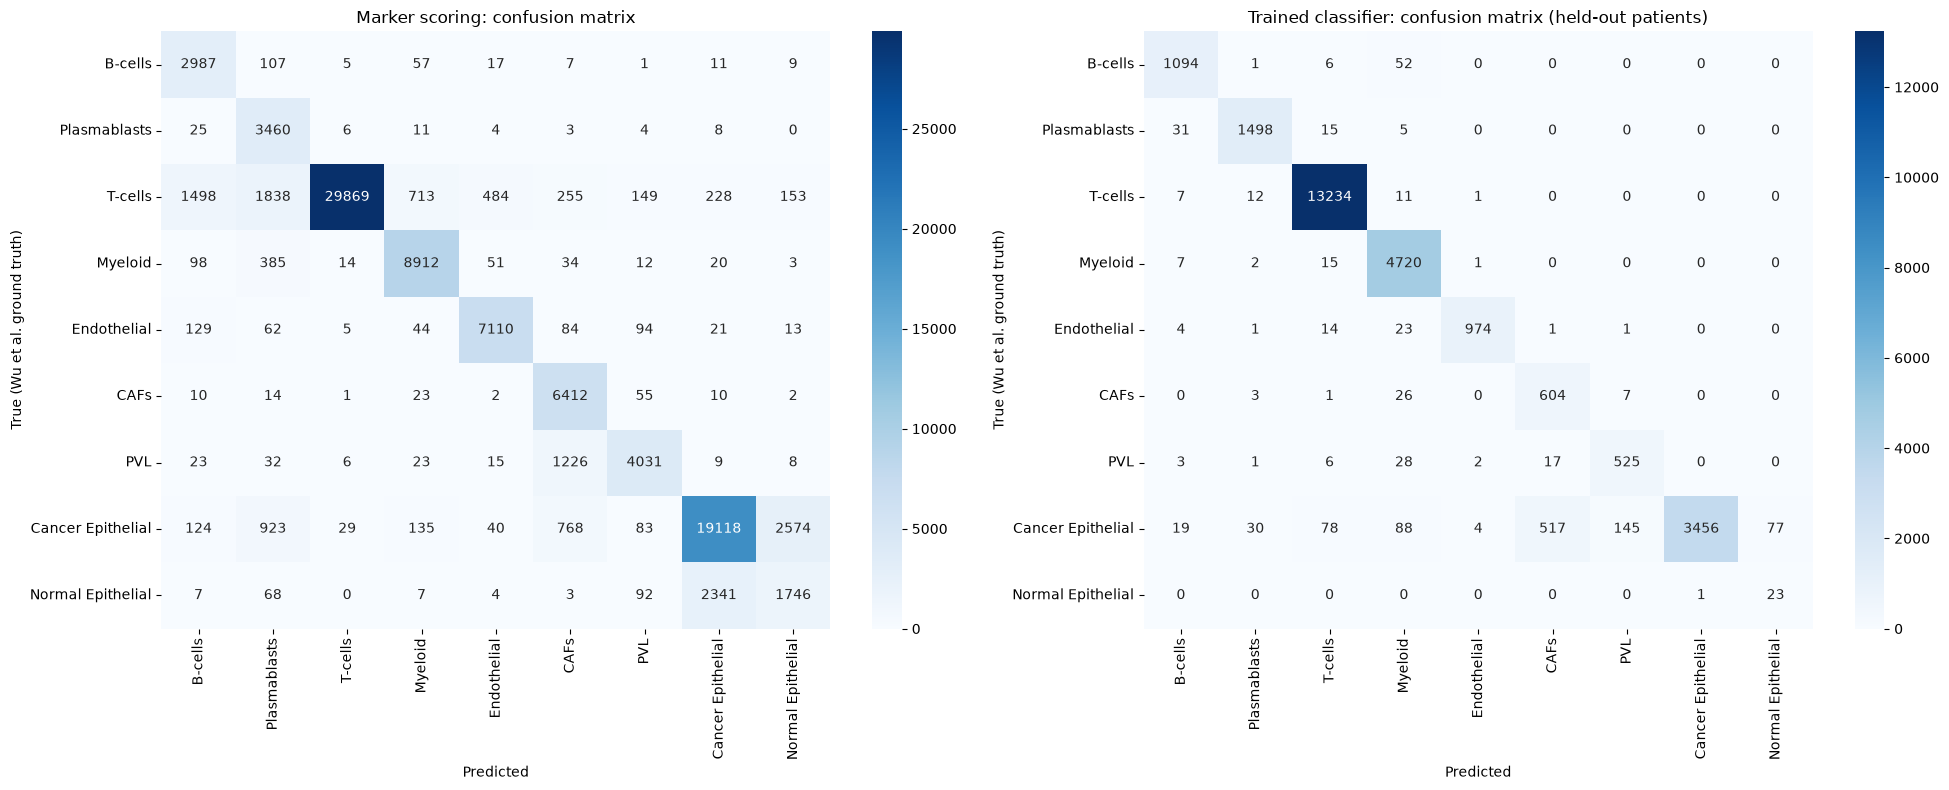

Saved annotation_confusion_matrices.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ct_order = list(marker_genes.keys())
cm_marker = confusion_matrix(adata.obs["celltype_major"], adata.obs["marker_pred"], labels=ct_order)
sns.heatmap(cm_marker, annot=True, fmt="d", xticklabels=ct_order, yticklabels=ct_order,
            cmap="Blues", ax=axes[0])
axes[0].set_title("Marker scoring: confusion matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True (Wu et al. ground truth)")

cm_clf = confusion_matrix(y[test_idx], y_pred, labels=ct_order)
sns.heatmap(cm_clf, annot=True, fmt="d", xticklabels=ct_order, yticklabels=ct_order,
            cmap="Blues", ax=axes[1])
axes[1].set_title("Trained classifier: confusion matrix (held-out patients)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True (Wu et al. ground truth)")

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "annotation_confusion_matrices.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Saved annotation_confusion_matrices.png")


The marker-scoring matrix makes the epithelial problem concrete: 2,341 Normal Epithelial cells predicted as Cancer Epithelial, against only 1,746 correctly called Normal — more wrong than right, in one specific direction. That's a real, informative negative result, not a bug: there's no marker gene for malignancy.

The PVL confusion has a more mundane explanation, found by checking the marker gene lists directly: PDGFRB was included as a marker for *both* CAFs and PVL, so any cell with high PDGFRB expression inflates both scores together, actively working against separating the two. 1,226 of 5,373 true PVL cells ended up called CAFs as a direct result — an easy, specific thing to fix in the marker list (drop PDGFRB from one of the two sets) if a cleaner number is wanted later, though the trained classifier doesn't share this problem (90% on PVL) since it learns feature weights from the data rather than inheriting a hand-picked overlapping gene choice.

## Saving the remaining results

The marker-scoring and classifier predictions are saved the same way CellTypist's were above — small, self-contained files rather than keeping the full object in memory through every downstream step.

In [ ]:
marker_results = pd.DataFrame({
    "marker_pred": adata.obs["marker_pred"].values,
    "celltype_major": adata.obs["celltype_major"].values,
}, index=adata.obs_names)
marker_results.to_csv(os.path.join(DATA_DIR, "marker_scoring_predictions.csv"))
print(f"Saved marker scoring results: {len(marker_results)} cells")


Saved marker scoring results: 98964 cells


In [ ]:
classifier_results = pd.DataFrame({
    "classifier_pred": y_pred,
    "celltype_major": y[test_idx],
    "donor_id": groups[test_idx],
}, index=adata.obs_names[test_idx])
classifier_results.to_csv(os.path.join(DATA_DIR, "classifier_predictions.csv"))
print(f"Saved trained classifier results: {len(classifier_results)} cells (held-out patients only)")

Saved trained classifier results: 27391 cells (held-out patients only)


## Final comparison

Reloading all three result files fresh, rather than continuing directly from the in-memory objects above — this keeps the comparison reproducible on its own and makes explicit exactly what's being compared to what.

Worth stating plainly rather than glossing over: these three methods were not evaluated on identical populations, and that's a deliberate choice rather than an inconsistency. Marker scoring covers all ~99,000 cells across all 9 categories; the trained classifier covers only its held-out-patient test cells (~27,000), also across all 9; CellTypist covers only the ~51,000 cells with immune ground truth, since that's the population it was actually built to handle. The fair three-way comparison is the immune-only subset specifically, computed separately below from the full-population numbers.

In [2]:
marker_results = pd.read_csv(os.path.join(DATA_DIR, "marker_scoring_predictions.csv"), index_col=0)
classifier_results = pd.read_csv(os.path.join(DATA_DIR, "classifier_predictions.csv"), index_col=0)
celltypist_results = pd.read_csv(os.path.join(DATA_DIR, "celltypist_predictions.csv"), index_col=0)

print(f"Marker scoring: {len(marker_results)} cells")
print(f"Trained classifier: {len(classifier_results)} cells (held-out patients)")
print(f"CellTypist: {len(celltypist_results)} cells")

immune_categories = ["B-cells", "T-cells", "Myeloid", "Plasmablasts"]


Marker scoring: 98964 cells
Trained classifier: 27391 cells (held-out patients)
CellTypist: 98964 cells


In [3]:
summary_rows = []

acc = accuracy_score(marker_results["celltype_major"], marker_results["marker_pred"])
ari = adjusted_rand_score(marker_results["celltype_major"], marker_results["marker_pred"])
summary_rows.append({"method": "Marker scoring", "scope": "all 9 categories",
                      "n_cells": len(marker_results), "accuracy": acc, "ARI": ari})

acc = accuracy_score(classifier_results["celltype_major"], classifier_results["classifier_pred"])
ari = adjusted_rand_score(classifier_results["celltype_major"], classifier_results["classifier_pred"])
summary_rows.append({"method": "Trained classifier (held-out patients)", "scope": "all 9 categories",
                      "n_cells": len(classifier_results), "accuracy": acc, "ARI": ari})


In [4]:
marker_immune = marker_results[marker_results["celltype_major"].isin(immune_categories)]
acc = accuracy_score(marker_immune["celltype_major"], marker_immune["marker_pred"])
ari = adjusted_rand_score(marker_immune["celltype_major"], marker_immune["marker_pred"])
summary_rows.append({"method": "Marker scoring (immune only)", "scope": "immune cells only",
                      "n_cells": len(marker_immune), "accuracy": acc, "ARI": ari})

clf_immune = classifier_results[classifier_results["celltype_major"].isin(immune_categories)]
acc = accuracy_score(clf_immune["celltype_major"], clf_immune["classifier_pred"])
ari = adjusted_rand_score(clf_immune["celltype_major"], clf_immune["classifier_pred"])
summary_rows.append({"method": "Trained classifier (immune only, held-out patients)", "scope": "immune cells only",
                      "n_cells": len(clf_immune), "accuracy": acc, "ARI": ari})

celltypist_eval = celltypist_results[celltypist_results["celltype_major"].isin(immune_categories)].copy()
celltypist_eval["celltypist_grouped"] = celltypist_eval["celltypist_grouped"].fillna("Unmapped")
acc = accuracy_score(celltypist_eval["celltype_major"], celltypist_eval["celltypist_grouped"])
ari = adjusted_rand_score(celltypist_eval["celltype_major"], celltypist_eval["celltypist_grouped"])
summary_rows.append({"method": "CellTypist (immune only)", "scope": "immune cells only",
                      "n_cells": len(celltypist_eval), "accuracy": acc, "ARI": ari})


In [5]:
summary_df = pd.DataFrame(summary_rows)
summary_df["accuracy"] = summary_df["accuracy"].round(3)
summary_df["ARI"] = summary_df["ARI"].round(3)
print(summary_df.to_string(index=False))

summary_df.to_csv(os.path.join(DATA_DIR, "final_annotation_benchmark_summary.csv"), index=False)
print(f"\nSaved to {DATA_DIR}/final_annotation_benchmark_summary.csv")


                                             method             scope  n_cells  accuracy   ARI
                                     Marker scoring  all 9 categories    98964     0.845 0.738
             Trained classifier (held-out patients)  all 9 categories    27391     0.954 0.950
                       Marker scoring (immune only) immune cells only    51438     0.879 0.702
Trained classifier (immune only, held-out patients) immune cells only    20712     0.992 0.986
                           CellTypist (immune only) immune cells only    51438     0.988 0.978

Saved to /content/drive/MyDrive/single-cell-breast-cancer-project/data/final_annotation_benchmark_summary.csv


On the shared immune-only ground: CellTypist and the trained classifier come out essentially tied at the top (~99% accuracy, ~0.98 ARI), with marker scoring clearly behind — and the gap is more visible in ARI (0.70) than in raw accuracy (0.88), which makes sense, since ARI penalizes chance agreement more strictly and is picking up on marker scoring's patterned errors (like the PDGFRB overlap above) more sharply than accuracy alone does.

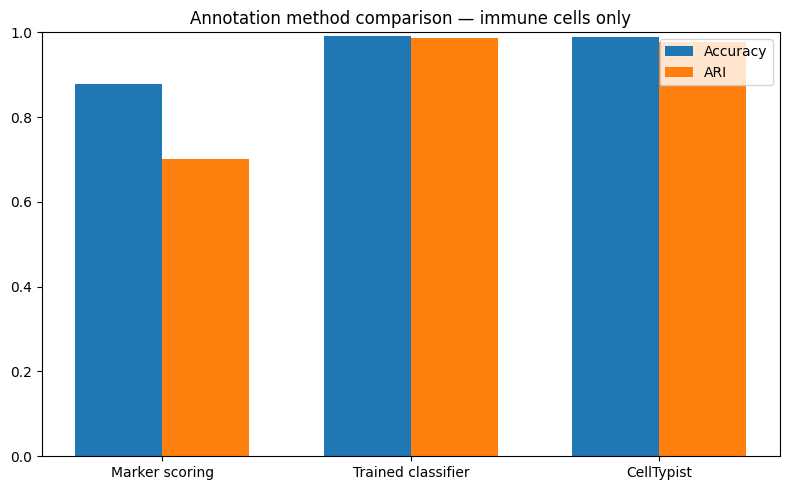

Saved annotation_method_comparison.png


In [6]:
immune_only = summary_df[summary_df["scope"] == "immune cells only"].copy()
immune_only["method_short"] = ["Marker scoring", "Trained classifier", "CellTypist"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(immune_only))
width = 0.35
ax.bar(x - width/2, immune_only["accuracy"], width, label="Accuracy")
ax.bar(x + width/2, immune_only["ARI"], width, label="ARI")
ax.set_xticks(x)
ax.set_xticklabels(immune_only["method_short"])
ax.set_ylim(0, 1)
ax.set_title("Annotation method comparison — immune cells only")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "annotation_method_comparison.png"), dpi=150, bbox_inches="tight")
plt.show()

print("Saved annotation_method_comparison.png")


## Summary

Three real, independently verified numbers on real data, each with a clear, principled evaluation scope rather than a single blended metric:

- **Marker scoring** — 84.5% overall, but a genuine, informative failure on Cancer vs. Normal Epithelial (40.9%), which reflects a real biological limitation of the approach rather than a coding error
- **Trained classifier** — 95.4% overall on entirely held-out patients, the strongest general-purpose performer across all 9 categories
- **CellTypist** — 98.8% specifically on immune cells, best-in-class for the population it was actually designed to handle

The epithelial finding matters beyond this notebook: none of these three methods is the right tool for separating malignant from normal epithelial cells. That distinction is picked up in the next notebook using the dataset's own copy-number-based calls instead — the actual basis for answering the project's central question.